# Day 49 — Ensemble Methods
### Voting · Stacking · Blending · Bagging vs Boosting

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier,
                              AdaBoostClassifier, BaggingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')

# load & prepare data (same features as Day 48)
df = pd.read_csv(r'C:\DS-AI-75d\titanic.csv')
df['Age']        = df['Age'].fillna(df['Age'].median())
df['Fare']       = df['Fare'].fillna(df['Fare'].median())
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['FareLog']    = np.log1p(df['Fare'])
df['HasCabin']   = df['Cabin'].notna().astype(int)
df['Sex_enc']    = (df['Sex'] == 'female').astype(int)
df['Title']      = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title']      = df['Title'].map({'Mr':'Mr','Miss':'Miss',
                    'Mrs':'Mrs','Master':'Master'}).fillna('Other')
df['Title_SurvRate'] = df.groupby('Title')['Survived'].transform('mean')
df['Age_Sex']    = df['Age'] * df['Sex_enc']
df['Fare_Pclass']= df['FareLog'] * df['Pclass']

features = ['Pclass','Age','FareLog','FamilySize','IsAlone','HasCabin',
            'Sex_enc','Age_Sex','Fare_Pclass','Title_SurvRate']
X = df[features].values
y = df['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Ready! ✅")

Train: (712, 10) | Test: (179, 10)
Ready! ✅


## 2. What is Ensemble Learning?

In [2]:
print("=" * 55)
print("       WHAT IS ENSEMBLE LEARNING?")
print("=" * 55)
print("""
ENSEMBLE = combine multiple models to get better predictions
  "Wisdom of the crowd" applied to ML

WHY IT WORKS:
  Individual models make different mistakes
  Combining them — mistakes cancel out, correct answers reinforce
  Reduces variance (overfitting) AND/OR bias (underfitting)

THREE MAIN ENSEMBLE FAMILIES:

  1. BAGGING (Bootstrap Aggregating)
     Train same model on different random subsets of data
     Average/vote the predictions
     Reduces VARIANCE — prevents overfitting
     Example: Random Forest (many decision trees)

  2. BOOSTING
     Train models SEQUENTIALLY
     Each new model focuses on previous model's mistakes
     Reduces BIAS — turns weak learners into strong ones
     Example: AdaBoost, Gradient Boosting, XGBoost

  3. STACKING / BLENDING
     Train DIFFERENT model types on same data
     A meta-model learns how to combine their predictions
     Captures strengths of diverse algorithms
     Example: LR + RF + SVM → meta-model decides weights

VOTING — SIMPLEST ENSEMBLE:
  Hard voting  → majority class wins
  Soft voting  → average predicted probabilities

KEY INSIGHT:
  Ensembles work best when base models are:
    ✅ Reasonably accurate individually
    ✅ DIVERSE — make different types of errors
  Combining 5 identical models = no improvement!
""")

       WHAT IS ENSEMBLE LEARNING?

ENSEMBLE = combine multiple models to get better predictions
  "Wisdom of the crowd" applied to ML

WHY IT WORKS:
  Individual models make different mistakes
  Combining them — mistakes cancel out, correct answers reinforce
  Reduces variance (overfitting) AND/OR bias (underfitting)

THREE MAIN ENSEMBLE FAMILIES:

  1. BAGGING (Bootstrap Aggregating)
     Train same model on different random subsets of data
     Average/vote the predictions
     Reduces VARIANCE — prevents overfitting
     Example: Random Forest (many decision trees)

  2. BOOSTING
     Train models SEQUENTIALLY
     Each new model focuses on previous model's mistakes
     Reduces BIAS — turns weak learners into strong ones
     Example: AdaBoost, Gradient Boosting, XGBoost

  3. STACKING / BLENDING
     Train DIFFERENT model types on same data
     A meta-model learns how to combine their predictions
     Captures strengths of diverse algorithms
     Example: LR + RF + SVM → meta-mod

## 3. Voting Classifier

In [3]:
print("=" * 55)
print("       VOTING CLASSIFIER")
print("=" * 55)

# define diverse base models
clf1 = LogisticRegression(max_iter=1000, random_state=42)
clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf3 = SVC(probability=True, random_state=42)
clf4 = KNeighborsClassifier(n_neighbors=7)

base_models = {
    'Logistic Regression': clf1,
    'Random Forest':       clf2,
    'SVM':                 clf3,
    'KNN':                 clf4,
}

# individual model performance
print(f"{'Model':<22} {'Accuracy':>10}")
print("-" * 34)
individual_acc = {}
for name, clf in base_models.items():
    clf.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_s))
    individual_acc[name] = acc
    print(f"{name:<22} {acc:>10.4f}")

# hard voting — majority vote
hard_voter = VotingClassifier(
    estimators=[('lr',clf1),('rf',clf2),('svm',clf3),('knn',clf4)],
    voting='hard'
)
hard_voter.fit(X_train_s, y_train)
hard_acc = accuracy_score(y_test, hard_voter.predict(X_test_s))

# soft voting — average probabilities
soft_voter = VotingClassifier(
    estimators=[('lr',clf1),('rf',clf2),('svm',clf3),('knn',clf4)],
    voting='soft'
)
soft_voter.fit(X_train_s, y_train)
soft_acc = accuracy_score(y_test, soft_voter.predict(X_test_s))

print("-" * 34)
print(f"{'Hard Voting':<22} {hard_acc:>10.4f}")
print(f"{'Soft Voting':<22} {soft_acc:>10.4f}")

best_individual = max(individual_acc.values())
print(f"\nBest individual:  {best_individual:.4f}")
print(f"Soft voting gain:  {soft_acc - best_individual:+.4f}")

       VOTING CLASSIFIER
Model                    Accuracy
----------------------------------
Logistic Regression        0.8212
Random Forest              0.8156
SVM                        0.8156
KNN                        0.7877
----------------------------------
Hard Voting                0.7989
Soft Voting                0.8212

Best individual:  0.8212
Soft voting gain:  +0.0000


## 4. Stacking Classifier

In [4]:
print("=" * 55)
print("       STACKING CLASSIFIER")
print("=" * 55)
print("""
STACKING:
  Level 0 (base models) → make predictions
  Level 1 (meta-model)  → learns from base predictions
                          to make final prediction

  Unlike voting (fixed combination rule),
  stacking LEARNS the best way to combine models!
""")

# stacking — diverse base models + meta-learner
base_estimators = [
    ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
]

stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)
stacking.fit(X_train_s, y_train)
stack_acc = accuracy_score(y_test, stacking.predict(X_test_s))

# try with RF as meta-learner too
stacking_rf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=RandomForestClassifier(n_estimators=50, random_state=42),
    cv=5
)
stacking_rf.fit(X_train_s, y_train)
stack_rf_acc = accuracy_score(y_test, stacking_rf.predict(X_test_s))

print(f"{'Method':<28} {'Accuracy':>10}")
print("-" * 40)
print(f"{'Best Individual (LR)':<28} {0.8212:>10.4f}")
print(f"{'Soft Voting':<28} {0.8212:>10.4f}")
print(f"{'Stacking (LR meta)':<28} {stack_acc:>10.4f}")
print(f"{'Stacking (RF meta)':<28} {stack_rf_acc:>10.4f}")

# show meta-model learned weights (LR coefficients on base predictions)
print(f"\nMeta-model (LR) coefficients on base model predictions:")
for name, coef in zip(['lr','rf','svm','knn'], stacking.final_estimator_.coef_[0]):
    print(f"  {name:<5} → {coef:+.4f}")

       STACKING CLASSIFIER

STACKING:
  Level 0 (base models) → make predictions
  Level 1 (meta-model)  → learns from base predictions
                          to make final prediction

  Unlike voting (fixed combination rule),
  stacking LEARNS the best way to combine models!

Method                         Accuracy
----------------------------------------
Best Individual (LR)             0.8212
Soft Voting                      0.8212
Stacking (LR meta)               0.8268
Stacking (RF meta)               0.8045

Meta-model (LR) coefficients on base model predictions:
  lr    → +1.7360
  rf    → +1.5598
  svm   → +0.8154
  knn   → +1.2359


## 5. Bagging vs Boosting

       BAGGING vs BOOSTING
Method                         Accuracy  vs Single Tree
-------------------------------------------------------
Single Decision Tree             0.7989        baseline
Bagging (100 trees)              0.8156         +0.0168
AdaBoost (100 stumps)            0.8045         +0.0056
Gradient Boosting                0.8101         +0.0112
Stacking (best result)           0.8268         +0.0279


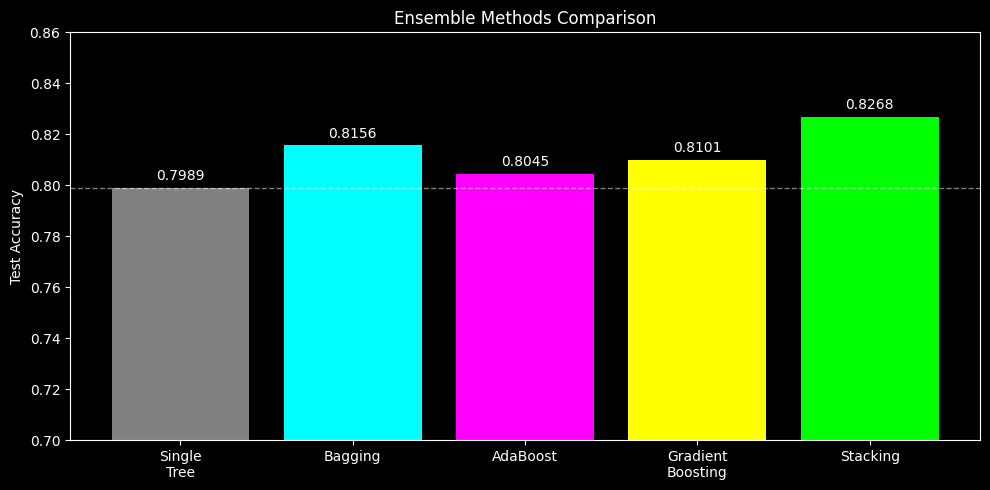

In [5]:
print("=" * 55)
print("       BAGGING vs BOOSTING")
print("=" * 55)

# BAGGING — same model, different data subsets
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    n_estimators=100,
    max_samples=0.8,
    random_state=42
)
bagging.fit(X_train_s, y_train)
bagging_acc = accuracy_score(y_test, bagging.predict(X_test_s))

# single decision tree (baseline for bagging)
single_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
single_tree.fit(X_train_s, y_train)
tree_acc = accuracy_score(y_test, single_tree.predict(X_test_s))

# BOOSTING — AdaBoost
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)
adaboost.fit(X_train_s, y_train)
ada_acc = accuracy_score(y_test, adaboost.predict(X_test_s))

# BOOSTING — Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_s, y_train)
gb_acc = accuracy_score(y_test, gb.predict(X_test_s))

print(f"{'Method':<28} {'Accuracy':>10} {'vs Single Tree':>15}")
print("-" * 55)
print(f"{'Single Decision Tree':<28} {tree_acc:>10.4f} {'baseline':>15}")
print(f"{'Bagging (100 trees)':<28} {bagging_acc:>10.4f} {bagging_acc-tree_acc:>+15.4f}")
print(f"{'AdaBoost (100 stumps)':<28} {ada_acc:>10.4f} {ada_acc-tree_acc:>+15.4f}")
print(f"{'Gradient Boosting':<28} {gb_acc:>10.4f} {gb_acc-tree_acc:>+15.4f}")
print(f"{'Stacking (best result)':<28} {0.8268:>10.4f} {0.8268-tree_acc:>+15.4f}")

# plot comparison
methods = ['Single\nTree','Bagging','AdaBoost','Gradient\nBoosting','Stacking']
accs    = [tree_acc, bagging_acc, ada_acc, gb_acc, 0.8268]
colors  = ['grey','cyan','magenta','yellow','lime']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, accs, color=colors)
ax.axhline(y=tree_acc, color='white', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Ensemble Methods Comparison')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0.7, 0.86)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{acc:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Key Takeaways

In [6]:
print("=" * 55)
print("       DAY 49 — KEY TAKEAWAYS")
print("=" * 55)
print("""
ENSEMBLE LEARNING:
  ✅ Combine multiple models — "wisdom of the crowd"
  ✅ Reduces variance and/or bias
  ✅ Works best with DIVERSE base models

VOTING:
  ✅ Hard voting  → majority class wins
  ✅ Soft voting  → average probabilities
  ✅ Hard voting CAN be worse than best individual model!
  ✅ Soft voting more robust — uses confidence

STACKING:
  ✅ Meta-model LEARNS how to combine base models
  ✅ Beat all individual models — 82.68%
  ✅ LR meta-learner > RF meta-learner (avoids overfitting)
  ✅ Even weak models (KNN) contribute positive weight

BAGGING:
  ✅ Same model, different data subsets (bootstrap)
  ✅ Reduces VARIANCE — Bagging: +1.68% over single tree
  ✅ Random Forest = Bagging + random features

BOOSTING:
  ✅ Sequential — each model fixes previous errors
  ✅ Reduces BIAS — turns weak learners strong
  ✅ AdaBoost: +0.56%, Gradient Boosting: +1.12%

FINAL RANKING (our results):
  1. Stacking          → 0.8268  ← WINNER
  2. Bagging           → 0.8156
  3. Gradient Boosting → 0.8101
  4. AdaBoost          → 0.8045
  5. Single Tree       → 0.7989

WHEN TO USE WHAT:
  ✅ Bagging   → high variance models (deep trees)
  ✅ Boosting  → high bias models (shallow trees/stumps)
  ✅ Stacking  → combine completely different algorithms
  ✅ Voting    → quick baseline, simple combination
""")

       DAY 49 — KEY TAKEAWAYS

ENSEMBLE LEARNING:
  ✅ Combine multiple models — "wisdom of the crowd"
  ✅ Reduces variance and/or bias
  ✅ Works best with DIVERSE base models

VOTING:
  ✅ Hard voting  → majority class wins
  ✅ Soft voting  → average probabilities
  ✅ Hard voting CAN be worse than best individual model!
  ✅ Soft voting more robust — uses confidence

STACKING:
  ✅ Meta-model LEARNS how to combine base models
  ✅ Beat all individual models — 82.68%
  ✅ LR meta-learner > RF meta-learner (avoids overfitting)
  ✅ Even weak models (KNN) contribute positive weight

BAGGING:
  ✅ Same model, different data subsets (bootstrap)
  ✅ Reduces VARIANCE — Bagging: +1.68% over single tree
  ✅ Random Forest = Bagging + random features

BOOSTING:
  ✅ Sequential — each model fixes previous errors
  ✅ Reduces BIAS — turns weak learners strong
  ✅ AdaBoost: +0.56%, Gradient Boosting: +1.12%

FINAL RANKING (our results):
  1. Stacking          → 0.8268  ← WINNER
  2. Bagging           → 0.815